# Customer Lifetime Value Modeling

## Customer Intelligence Analytics

This notebook estimates future customer value for the Online Retail II
customer base.

The project uses probabilistic Buy-Till-You-Die models:

- **BG/NBD** to estimate future purchasing activity.
- **Gamma-Gamma** to estimate expected transaction value.
- Both models are combined to estimate expected future customer revenue.

### Important interpretation

Because product cost and gross-margin information are unavailable, the
resulting CLV represents **expected future revenue**, not expected future
profit.

The analysis therefore distinguishes between:

- Historical customer revenue.
- Expected future purchases.
- Expected future transaction value.
- Expected 12-month revenue CLV.

In [1]:
from pathlib import Path
import json
import os
import tempfile

PYTENSOR_CACHE_DIR = (
    Path(tempfile.gettempdir())
    / "customer_intelligence_pytensor"
)
PYTENSOR_CACHE_DIR.mkdir(parents=True, exist_ok=True)
os.environ.setdefault(
    "PYTENSOR_FLAGS",
    f"base_compiledir={PYTENSOR_CACHE_DIR.as_posix()}",
)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
)

from pymc_marketing import clv


pd.set_option("display.max_columns", 100)
pd.set_option("display.max_rows", 100)
pd.set_option(
    "display.float_format",
    lambda value: f"{value:,.3f}",
)


RANDOM_STATE = 42


PROJECT_ROOT = Path.cwd()

if PROJECT_ROOT.name.lower() == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent


CUSTOMER_SALES_PATH = (
    PROJECT_ROOT
    / "data"
    / "processed"
    / "customer_sales.parquet"
)

RFM_SEGMENTS_PATH = (
    PROJECT_ROOT
    / "data"
    / "processed"
    / "rfm_customer_segments.parquet"
)

ML_SEGMENTS_PATH = (
    PROJECT_ROOT
    / "data"
    / "processed"
    / "ml_customer_segments.parquet"
)

OUTPUT_PATH = (
    PROJECT_ROOT
    / "data"
    / "processed"
    / "customer_clv.parquet"
)

REPORTS_DIR = PROJECT_ROOT / "reports"
FIGURES_DIR = REPORTS_DIR / "figures"
REPORTS_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)


print(f"Customer sales: {CUSTOMER_SALES_PATH}")

g++ not available, if using conda: `conda install gxx`


Customer sales: C:\Users\omary\Documents\VS Code\customer-intelligence-analytics\data\processed\customer_sales.parquet


C:\Users\omary\Documents\VS Code\customer-intelligence-analytics\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
customer_sales = pd.read_parquet(
    CUSTOMER_SALES_PATH
)


customer_sales["invoice_date"] = pd.to_datetime(
    customer_sales["invoice_date"]
)


customer_sales["invoice_key"] = (
    customer_sales["source_period"].astype("string")
    + "::"
    + customer_sales["invoice"].astype("string")
)


print(f"Sales lines:  {len(customer_sales):,}")

print(
    f"Customers:    "
    f"{customer_sales['customer_id'].nunique():,}"
)

print(
    f"Invoices:     "
    f"{customer_sales['invoice_key'].nunique():,}"
)

print(
    f"Revenue:      "
    f"{customer_sales['line_amount'].sum():,.2f}"
)

Sales lines:  793,609
Customers:    5,878
Invoices:     37,745
Revenue:      17,685,460.64


In [3]:
orders = (
    customer_sales
    .groupby(
        [
            "customer_id",
            "invoice_key",
        ],
        observed=True,
    )
    .agg(
        purchase_datetime=("invoice_date", "min"),
        order_value=("line_amount", "sum"),
        units=("quantity", "sum"),
    )
    .reset_index()
)


orders["purchase_date"] = (
    orders["purchase_datetime"]
    .dt.normalize()
)


print(f"Orders: {len(orders):,}")

display(orders.head())

Orders: 37,745


,customer_id,invoice_key,purchase_datetime,order_value,units,purchase_date
0,12346,2009-2010::491725,2009-12-14 08:34:00,45.000,10,2009-12-14
1,12346,2009-2010::491742,2009-12-14 11:00:00,22.500,5,2009-12-14
2,12346,2009-2010::491744,2009-12-14 11:02:00,22.500,5,2009-12-14
3,12346,2009-2010::492718,2009-12-18 10:47:00,22.500,5,2009-12-18
4,12346,2009-2010::492722,2009-12-18 10:55:00,1.000,1,2009-12-18


In [4]:
daily_purchases = (
    orders
    .groupby(
        [
            "customer_id",
            "purchase_date",
        ],
        observed=True,
    )
    .agg(
        monetary_value=("order_value", "sum"),
        orders=("invoice_key", "nunique"),
        units=("units", "sum"),
    )
    .reset_index()
)


print(
    f"Customer purchase-days: "
    f"{len(daily_purchases):,}"
)

display(daily_purchases.head())

Customer purchase-days: 33,107


,customer_id,purchase_date,monetary_value,orders,units
0,12346,2009-12-14,90.000,3,20
1,12346,2009-12-18,23.500,2,6
2,12346,2010-01-04,45.000,2,10
3,12346,2010-01-14,22.500,1,5
4,12346,2010-01-22,22.500,1,5


In [5]:
historical_value = (
    orders
    .groupby(
        "customer_id",
        observed=True,
    )
    .agg(
        historical_orders=("invoice_key", "nunique"),
        historical_revenue=("order_value", "sum"),
        historical_units=("units", "sum"),
        first_purchase=("purchase_datetime", "min"),
        last_purchase=("purchase_datetime", "max"),
    )
    .reset_index()
)


historical_value["historical_aov"] = (
    historical_value["historical_revenue"]
    / historical_value["historical_orders"]
)


display(
    historical_value
    .sort_values(
        "historical_revenue",
        ascending=False,
    )
    .head(20)
)

,customer_id,historical_orders,historical_revenue,historical_units,first_purchase,last_purchase,historical_aov
5692,18102,149,"608,821.650",188340,2009-12-01 09:24:00,2011-12-09 11:50:00,"4,086.051"
2277,14646,151,"528,602.520",367193,2009-12-02 16:52:00,2011-12-08 12:12:00,"3,500.679"
1789,14156,157,"313,759.820",165873,2009-12-01 12:30:00,2011-11-30 10:54:00,"1,998.470"
2538,14911,406,"295,832.390",149949,2009-12-01 11:41:00,2011-12-08 15:54:00,728.651
5050,17450,53,"246,813.090",84700,2010-09-27 16:59:00,2011-12-01 13:29:00,"4,656.851"
1331,13694,144,"196,482.810",189205,2009-12-04 15:26:00,2011-12-06 09:32:00,"1,364.464"
5109,17511,62,"175,603.550",119656,2009-12-02 10:52:00,2011-12-07 10:12:00,"2,832.315"
4061,16446,2,"168,472.500",80997,2011-05-18 09:52:00,2011-12-09 09:15:00,"84,236.250"
4295,16684,55,"147,142.770",104810,2009-12-07 12:56:00,2011-12-05 14:06:00,"2,675.323"
68,12415,28,"144,458.370",91447,2010-06-30 08:30:00,2011-11-15 14:22:00,"5,159.227"


In [6]:
clv_rfm = clv.utils.rfm_summary(
    daily_purchases,
    customer_id_col="customer_id",
    datetime_col="purchase_date",
    monetary_value_col="monetary_value",
    time_unit="D",
)


print(f"CLV customers: {len(clv_rfm):,}")

display(clv_rfm.head(20))

CLV customers: 5,878


,customer_id,frequency,recency,T,monetary_value
0,12346,7.000,400.000,725.000,"11,066.637"
1,12347,7.000,402.000,404.000,717.399
2,12348,4.000,363.000,438.000,449.310
3,12349,3.000,571.000,589.000,"1,120.057"
4,12350,0.000,0.000,310.000,0.000
5,12351,0.000,0.000,375.000,0.000
6,12352,8.000,356.000,392.000,338.261
7,12353,1.000,204.000,408.000,89.000
8,12354,0.000,0.000,232.000,0.000
9,12355,1.000,353.000,567.000,459.400


In [7]:
assert clv_rfm["customer_id"].is_unique

assert (clv_rfm["frequency"] >= 0).all()

assert (clv_rfm["recency"] >= 0).all()

assert (clv_rfm["T"] >= 0).all()

assert (
    clv_rfm["recency"]
    <= clv_rfm["T"]
).all()


assert len(clv_rfm) == (
    daily_purchases["customer_id"].nunique()
)


print(
    "CLV input validation passed successfully."
)

CLV input validation passed successfully.


In [8]:
display(
    clv_rfm[
        [
            "frequency",
            "recency",
            "T",
            "monetary_value",
        ]
    ]
    .describe(
        percentiles=[
            0.25,
            0.50,
            0.75,
            0.90,
            0.95,
            0.99,
        ]
    )
    .T
)

,count,mean,std,min,25%,50%,75%,90%,95%,99%,max
frequency,"5,878.000",4.632,10.000,0.000,0.000,2.000,5.000,11.000,18.000,38.000,254.000
recency,"5,878.000",273.394,258.964,0.000,0.000,221.000,512.000,667.000,713.000,732.000,738.000
T,"5,878.000",474.260,223.091,0.000,313.000,530.000,668.000,730.000,735.000,738.000,738.000
monetary_value,"5,878.000",317.721,"2,256.710",0.000,0.000,211.934,374.290,601.315,839.653,"1,807.350","168,469.600"


In [9]:
repeat_summary = pd.Series(
    {
        "CLV customers": len(clv_rfm),

        "One purchase-period only": int(
            (clv_rfm["frequency"] == 0).sum()
        ),

        "Repeat customers": int(
            (clv_rfm["frequency"] > 0).sum()
        ),

        "Repeat customer rate (%)": float(
            (
                clv_rfm["frequency"] > 0
            ).mean()
            * 100
        ),
    },
    name="value",
)


display(repeat_summary.to_frame())

,value
CLV customers,"5,878.000"
One purchase-period only,"1,689.000"
Repeat customers,"4,189.000"
Repeat customer rate (%),71.266


In [10]:
CALIBRATION_END = "2011-06-01"


clv_train_test = (
    clv.utils.rfm_train_test_split(
        daily_purchases,
        customer_id_col="customer_id",
        datetime_col="purchase_date",
        monetary_value_col="monetary_value",
        train_period_end=CALIBRATION_END,
        time_unit="D",
    )
)


display(clv_train_test.head())

,customer_id,frequency,recency,T,monetary_value,test_frequency,test_monetary_value,test_T
0,12346,7.000,400.000,534.000,"11,066.637",0.000,0.000,191.000
1,12347,3.000,158.000,213.000,845.073,4.000,621.642,191.000
2,12348,3.000,190.000,247.000,495.747,1.000,310.000,191.000
3,12349,2.000,182.000,398.000,801.310,1.000,"1,757.550",191.000
4,12350,0.000,0.000,119.000,0.000,0.000,0.000,191.000


In [11]:
validation_bgm = clv.BetaGeoModel()


validation_bgm.fit(
    data=clv_train_test[
        [
            "customer_id",
            "frequency",
            "recency",
            "T",
        ]
    ],
    method="map",
    progressbar=False,
    random_seed=RANDOM_STATE,
)


print("Validation BG/NBD fitted successfully.")

display(
    validation_bgm.fit_summary()
)

C:\Users\omary\Documents\VS Code\customer-intelligence-analytics\.venv\Lib\site-packages\pymc_marketing\clv\models\basic.py:116: UserWarning: T=0 is uninformative for model fitting. This occurs when a customer makes a purchase in the final observed time period.
  self._validate_rfm_data(data)


Validation BG/NBD fitted successfully.


alpha           60.269
phi_dropout      0.049
kappa_dropout    2.989
r                0.643
a                0.147
b                2.842
Name: value, dtype: float64

In [12]:
validation_expected_purchases = (
    validation_bgm.expected_purchases(
        data=clv_train_test[
            [
                "customer_id",
                "frequency",
                "recency",
                "T",
            ]
        ],
        future_t=clv_train_test["test_T"],
    )
    .mean(
        dim=[
            "chain",
            "draw",
        ]
    )
    .values
)


clv_validation = clv_train_test[
    [
        "customer_id",
        "test_frequency",
        "test_T",
    ]
].copy()


clv_validation[
    "predicted_test_frequency"
] = validation_expected_purchases


display(clv_validation.head(20))

,customer_id,test_frequency,test_T,predicted_test_frequency
0,12346,0.000,191.000,2.158
1,12347,4.000,191.000,2.303
2,12348,1.000,191.000,2.064
3,12349,1.000,191.000,0.895
4,12350,0.000,191.000,0.662
5,12351,0.000,191.000,0.490
6,12352,3.000,191.000,3.521
7,12353,0.000,191.000,1.041
8,12354,0.000,191.000,1.148
9,12355,0.000,191.000,0.668


In [13]:
purchase_mae = mean_absolute_error(
    clv_validation["test_frequency"],
    clv_validation["predicted_test_frequency"],
)


purchase_rmse = np.sqrt(
    mean_squared_error(
        clv_validation["test_frequency"],
        clv_validation[
            "predicted_test_frequency"
        ],
    )
)


actual_total_purchases = (
    clv_validation["test_frequency"].sum()
)


predicted_total_purchases = (
    clv_validation[
        "predicted_test_frequency"
    ].sum()
)


purchase_validation_metrics = pd.Series(
    {
        "Customers": len(clv_validation),

        "MAE": purchase_mae,

        "RMSE": purchase_rmse,

        "Actual holdout purchases": (
            actual_total_purchases
        ),

        "Predicted holdout purchases": (
            predicted_total_purchases
        ),

        "Aggregate prediction error (%)": (
            (
                predicted_total_purchases
                - actual_total_purchases
            )
            / actual_total_purchases
            * 100
        ),
    },
    name="value",
)


display(
    purchase_validation_metrics.to_frame()
)

,value
Customers,"4,937.000"
MAE,1.078
RMSE,1.843
Actual holdout purchases,"8,111.000"
Predicted holdout purchases,"7,960.962"
Aggregate prediction error (%),-1.850


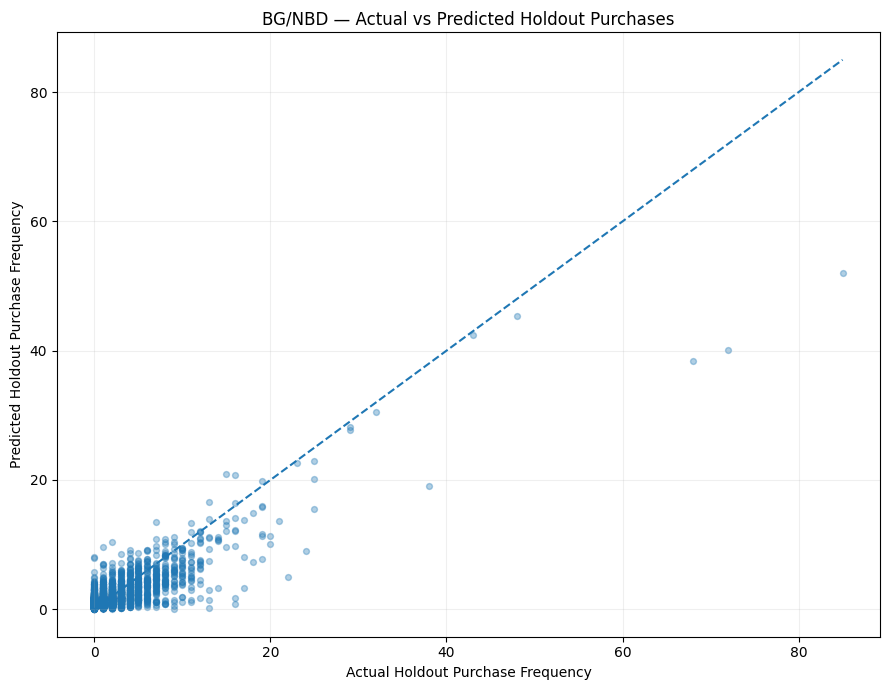

In [14]:
plt.figure(figsize=(9, 7))

plt.scatter(
    clv_validation["test_frequency"],
    clv_validation[
        "predicted_test_frequency"
    ],
    alpha=0.35,
    s=18,
)

maximum_value = max(
    clv_validation["test_frequency"].max(),
    clv_validation[
        "predicted_test_frequency"
    ].max(),
)


plt.plot(
    [0, maximum_value],
    [0, maximum_value],
    linestyle="--",
)


plt.title(
    "BG/NBD — Actual vs Predicted Holdout Purchases"
)

plt.xlabel("Actual Holdout Purchase Frequency")
plt.ylabel("Predicted Holdout Purchase Frequency")

plt.grid(alpha=0.2)
plt.tight_layout()

plt.savefig(
    FIGURES_DIR
    / "clv_bgnbd_holdout_validation.png",
    dpi=160,
    bbox_inches="tight",
)

plt.show()

In [15]:
gamma_data = clv_rfm.loc[
    (clv_rfm["frequency"] > 0)
    & (clv_rfm["monetary_value"] > 0)
].copy()


frequency_monetary_correlation = (
    gamma_data[
        [
            "frequency",
            "monetary_value",
        ]
    ]
    .corr()
    .loc[
        "frequency",
        "monetary_value",
    ]
)


print(
    "Frequency / Monetary Value correlation: "
    f"{frequency_monetary_correlation:.4f}"
)

print(
    f"Gamma-Gamma eligible customers: "
    f"{len(gamma_data):,}"
)

Frequency / Monetary Value correlation: 0.0233
Gamma-Gamma eligible customers: 4,189


In [16]:
if abs(frequency_monetary_correlation) < 0.30:
    print(
        "Gamma-Gamma assumption looks acceptable."
    )
else:
    print(
        "WARNING: Frequency and monetary value "
        "are strongly related. Review before fitting "
        "Gamma-Gamma."
    )

Gamma-Gamma assumption looks acceptable.


In [17]:
final_bgm = clv.BetaGeoModel()

final_bgm.fit(
    data=clv_rfm[
        [
            "customer_id",
            "frequency",
            "recency",
            "T",
        ]
    ],
    method="map",
    progressbar=False,
    random_seed=RANDOM_STATE,
)

print("Final BG/NBD model fitted successfully.")

display(
    final_bgm.fit_summary()
)

C:\Users\omary\Documents\VS Code\customer-intelligence-analytics\.venv\Lib\site-packages\pymc_marketing\clv\models\basic.py:116: UserWarning: T=0 is uninformative for model fitting. This occurs when a customer makes a purchase in the final observed time period.
  self._validate_rfm_data(data)


Final BG/NBD model fitted successfully.


alpha           59.188
phi_dropout      0.045
kappa_dropout    2.312
r                0.638
a                0.104
b                2.207
Name: value, dtype: float64

In [18]:
probability_alive_da = (
    final_bgm.expected_probability_alive(
        data=clv_rfm[
            [
                "customer_id",
                "frequency",
                "recency",
                "T",
            ]
        ]
    )
)


probability_alive = (
    probability_alive_da
    .mean(
        dim=[
            "chain",
            "draw",
        ]
    )
    .values
)


clv_results = clv_rfm.copy()

clv_results["probability_alive"] = (
    probability_alive
)


display(
    clv_results[
        [
            "customer_id",
            "frequency",
            "recency",
            "T",
            "probability_alive",
        ]
    ]
    .sort_values(
        "probability_alive"
    )
    .head(20)
)

,customer_id,frequency,recency,T,probability_alive
487,12835,36.000,309.000,736.000,0.000
5048,17448,17.000,148.000,645.000,0.000
743,13093,42.000,460.000,735.000,0.000
2221,14590,18.000,308.000,732.000,0.000
5442,17850,22.000,362.000,734.000,0.000
4364,16754,18.000,269.000,641.000,0.000
3255,15633,12.000,222.000,731.000,0.000
1793,14160,6.000,88.000,698.000,0.001
5641,18051,6.000,96.000,730.000,0.001
2639,15015,10.000,224.000,725.000,0.002


In [19]:
prediction_horizons = {
    "expected_purchases_90d": 90,
    "expected_purchases_180d": 180,
    "expected_purchases_365d": 365,
}


for column_name, future_days in (
    prediction_horizons.items()
):

    prediction = (
        final_bgm.expected_purchases(
            data=clv_rfm[
                [
                    "customer_id",
                    "frequency",
                    "recency",
                    "T",
                ]
            ],
            future_t=future_days,
        )
    )

    clv_results[column_name] = (
        prediction
        .mean(
            dim=[
                "chain",
                "draw",
            ]
        )
        .values
    )


display(
    clv_results[
        [
            "customer_id",
            "frequency",
            "probability_alive",
            "expected_purchases_90d",
            "expected_purchases_180d",
            "expected_purchases_365d",
        ]
    ]
    .sort_values(
        "expected_purchases_365d",
        ascending=False,
    )
    .head(20)
)

,customer_id,frequency,probability_alive,expected_purchases_90d,expected_purchases_180d,expected_purchases_365d
2538,14911,254.000,0.999,28.569,56.838,114.126
400,12748,201.000,0.999,22.709,45.179,90.712
2935,15311,195.000,0.999,21.951,43.670,87.687
5433,17841,192.000,0.999,21.638,43.048,86.435
2237,14606,180.000,0.999,20.314,40.415,81.148
739,13089,131.000,0.999,14.780,29.405,59.042
2158,14527,120.000,0.999,13.544,26.946,54.105
1789,14156,120.000,0.997,13.497,26.853,53.919
622,12971,98.000,0.998,11.253,22.386,44.944
1434,13798,98.000,0.999,11.158,22.197,44.568


## Gamma-Gamma expected transaction value

The spend model is fitted only on customers with at least one repeat purchase-day and positive repeat monetary value. Their frequency/monetary correlation is close to zero, which supports the model's independence assumption.

After fitting, all customers are scored. For the 1,689 customers without repeat behavior, the estimate is driven by the learned population distribution rather than customer-specific repeat-spend evidence, so those values carry greater uncertainty.

In [20]:
gamma_gamma_model = clv.GammaGammaModel()


gamma_gamma_model.fit(
    data=gamma_data[
        [
            "customer_id",
            "frequency",
            "monetary_value",
        ]
    ],
    method="map",
    progressbar=False,
    random_seed=RANDOM_STATE,
)


print(
    "Final Gamma-Gamma model fitted successfully."
)

display(
    gamma_gamma_model.fit_summary()
)

Final Gamma-Gamma model fitted successfully.


p     5.641
q     2.332
v   103.497
Name: value, dtype: float64

In [21]:
expected_spend_da = (
    gamma_gamma_model.expected_customer_spend(
        data=clv_rfm[
            [
                "customer_id",
                "frequency",
                "monetary_value",
            ]
        ]
    )
)


expected_spend = (
    expected_spend_da
    .mean(
        dim=[
            "chain",
            "draw",
        ]
    )
    .values
)


clv_results[
    "expected_transaction_value"
] = expected_spend


display(
    clv_results[
        [
            "customer_id",
            "frequency",
            "monetary_value",
            "expected_transaction_value",
        ]
    ]
    .sort_values(
        "expected_transaction_value",
        ascending=False,
    )
    .head(20)
)

,customer_id,frequency,monetary_value,expected_transaction_value
4061,16446,1.000,"168,469.600","136,380.832"
3371,15749,1.000,"21,535.900","17,506.939"
0,12346,7.000,"11,066.637","10,719.936"
5692,18102,66.000,"9,189.930","9,158.743"
1538,13902,4.000,"8,416.400","7,971.842"
5050,17450,30.000,"6,919.190","6,868.596"
189,12536,1.000,"8,322.120","6,816.584"
68,12415,22.000,"6,460.529","6,396.601"
2277,14646,90.000,"5,809.905","5,795.854"
11,12357,1.000,"6,207.670","5,105.929"


In [22]:
MONTHLY_DISCOUNT_RATE = 0.0

In [23]:
clv_12m_da = (
    gamma_gamma_model
    .expected_customer_lifetime_value(
        transaction_model=final_bgm,
        data=clv_rfm[
            [
                "customer_id",
                "frequency",
                "recency",
                "T",
                "monetary_value",
            ]
        ],
        future_t=12,
        discount_rate=MONTHLY_DISCOUNT_RATE,
        time_unit="D",
    )
)


expected_clv_12m = (
    clv_12m_da
    .mean(
        dim=[
            "chain",
            "draw",
        ]
    )
    .values
)


clv_results[
    "expected_revenue_clv_12m"
] = expected_clv_12m

In [24]:
clv_results = clv_results.merge(
    historical_value[
        [
            "customer_id",
            "historical_orders",
            "historical_revenue",
            "historical_units",
            "historical_aov",
            "first_purchase",
            "last_purchase",
        ]
    ],
    on="customer_id",
    how="left",
    validate="one_to_one",
)

In [25]:
display(
    clv_results[
        [
            "customer_id",
            "historical_revenue",
            "historical_orders",
            "probability_alive",
            "expected_purchases_365d",
            "expected_transaction_value",
            "expected_revenue_clv_12m",
        ]
    ]
    .sort_values(
        "expected_revenue_clv_12m",
        ascending=False,
    )
    .head(25)
)

,customer_id,historical_revenue,historical_orders,probability_alive,expected_purchases_365d,expected_transaction_value,expected_revenue_clv_12m
4061,16446,"168,472.500",2,0.955,2.070,"136,380.832","282,508.432"
5692,18102,"608,821.650",149,0.998,29.841,"9,158.743","273,487.408"
2277,14646,"528,602.520",151,0.999,40.647,"5,795.854","235,743.545"
5050,17450,"246,813.090",53,0.995,21.694,"6,868.596","149,104.658"
1731,14096,"65,164.790",17,0.991,34.973,"4,018.617","140,633.861"
1789,14156,"313,759.820",157,0.997,53.919,"2,601.520","140,366.175"
2538,14911,"295,832.390",406,0.999,114.126,"1,161.135","132,604.524"
1331,13694,"196,482.810",144,0.998,37.136,"2,359.749","87,689.561"
68,12415,"144,458.370",28,0.989,13.570,"6,396.601","86,857.053"
5109,17511,"175,603.550",62,0.998,22.688,"3,435.748","78,002.037"


In [26]:
display(
    clv_results[
        [
            "historical_revenue",
            "probability_alive",
            "expected_purchases_90d",
            "expected_purchases_365d",
            "expected_transaction_value",
            "expected_revenue_clv_12m",
        ]
    ]
    .describe(
        percentiles=[
            0.25,
            0.50,
            0.75,
            0.90,
            0.95,
            0.99,
        ]
    )
    .T
)

,count,mean,std,min,25%,50%,75%,90%,95%,99%,max
historical_revenue,"5,878.000","3,008.755","14,731.924",2.950,345.115,887.390,"2,298.005","5,557.650","9,504.783","29,710.548","608,821.650"
probability_alive,"5,878.000",0.911,0.171,0.000,0.929,0.976,1.000,1.000,1.000,1.000,1.000
expected_purchases_90d,"5,878.000",0.798,1.221,0.000,0.175,0.454,0.973,1.777,2.582,5.336,28.569
expected_purchases_365d,"5,878.000",3.161,4.852,0.000,0.698,1.792,3.861,7.023,10.170,20.813,114.126
expected_transaction_value,"5,878.000",442.621,"1,828.722",18.810,251.530,416.066,438.460,587.404,811.708,"1,662.285","136,380.832"
expected_revenue_clv_12m,"5,878.000","1,625.817","7,843.244",0.000,225.165,574.083,"1,343.856","2,931.124","4,873.606","13,754.165","282,508.432"


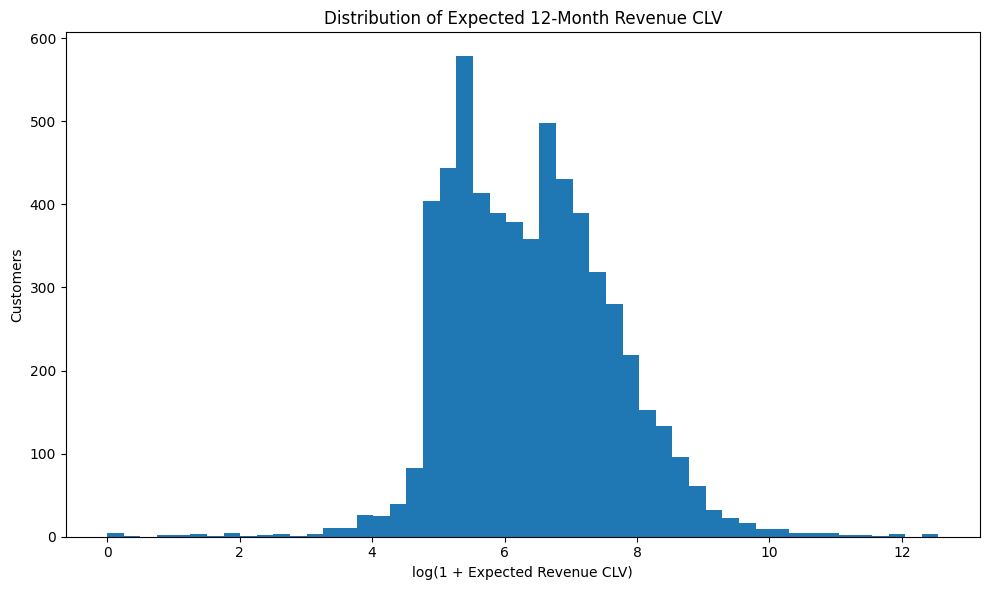

In [27]:
plt.figure(figsize=(10, 6))

plt.hist(
    np.log1p(
        clv_results[
            "expected_revenue_clv_12m"
        ]
    ),
    bins=50,
)

plt.title(
    "Distribution of Expected 12-Month Revenue CLV"
)

plt.xlabel(
    "log(1 + Expected Revenue CLV)"
)

plt.ylabel("Customers")

plt.tight_layout()

plt.savefig(
    FIGURES_DIR
    / "clv_12m_distribution.png",
    dpi=160,
    bbox_inches="tight",
)

plt.show()

In [28]:
clv_ranked = clv_results.sort_values(
    "expected_revenue_clv_12m",
    ascending=False,
).reset_index(drop=True)

total_predictive_revenue = clv_ranked[
    "expected_revenue_clv_12m"
].sum()

clv_concentration = pd.DataFrame(
    [
        {
            "top_customer_share": share,
            "customers": max(1, int(np.ceil(len(clv_ranked) * share))),
        }
        for share in [0.01, 0.05, 0.10, 0.20]
    ]
)

clv_concentration["predictive_revenue_share_pct"] = [
    clv_ranked.head(customer_count)[
        "expected_revenue_clv_12m"
    ].sum()
    / total_predictive_revenue
    * 100
    for customer_count in clv_concentration["customers"]
]

display(clv_concentration)

,top_customer_share,customers,predictive_revenue_share_pct
0,0.010,59,30.487
1,0.050,294,48.228
2,0.100,588,59.745
3,0.200,1176,73.383


In [29]:
display(
    clv_results[
        [
            "customer_id",
            "historical_revenue",
            "probability_alive",
            "expected_purchases_365d",
            "expected_transaction_value",
            "expected_revenue_clv_12m",
        ]
    ]
    .sort_values(
        "expected_revenue_clv_12m",
        ascending=False,
    )
    .head(20)
)

,customer_id,historical_revenue,probability_alive,expected_purchases_365d,expected_transaction_value,expected_revenue_clv_12m
4061,16446,"168,472.500",0.955,2.070,"136,380.832","282,508.432"
5692,18102,"608,821.650",0.998,29.841,"9,158.743","273,487.408"
2277,14646,"528,602.520",0.999,40.647,"5,795.854","235,743.545"
5050,17450,"246,813.090",0.995,21.694,"6,868.596","149,104.658"
1731,14096,"65,164.790",0.991,34.973,"4,018.617","140,633.861"
1789,14156,"313,759.820",0.997,53.919,"2,601.520","140,366.175"
2538,14911,"295,832.390",0.999,114.126,"1,161.135","132,604.524"
1331,13694,"196,482.810",0.998,37.136,"2,359.749","87,689.561"
68,12415,"144,458.370",0.989,13.570,"6,396.601","86,857.053"
5109,17511,"175,603.550",0.998,22.688,"3,435.748","78,002.037"


## Predictive CLV value tiers

Expected 12-month revenue is extremely right-skewed, so fixed currency cutoffs would be arbitrary and unstable. The tiers below are recalculated from the **actual predictive CLV distribution**: the lower half is Developing, the 50th–80th percentiles are Core, the 80th–95th percentiles are High, and the top 5% is Strategic.

These are forward-looking value tiers. They are intentionally kept separate from the existing RFM value tier, which describes historical behavior.

In [30]:
clv_percentiles = (
    clv_results["expected_revenue_clv_12m"]
    .quantile([0.50, 0.80, 0.95])
)

clv_p50 = float(clv_percentiles.loc[0.50])
clv_p80 = float(clv_percentiles.loc[0.80])
clv_p95 = float(clv_percentiles.loc[0.95])

assert clv_p50 < clv_p80 < clv_p95

clv_results["clv_value_tier"] = np.select(
    [
        clv_results["expected_revenue_clv_12m"] <= clv_p50,
        clv_results["expected_revenue_clv_12m"] <= clv_p80,
        clv_results["expected_revenue_clv_12m"] <= clv_p95,
    ],
    ["Developing", "Core", "High"],
    default="Strategic",
)

CLV_TIER_ORDER = [
    "Developing",
    "Core",
    "High",
    "Strategic",
]

clv_results["clv_value_tier"] = pd.Categorical(
    clv_results["clv_value_tier"],
    categories=CLV_TIER_ORDER,
    ordered=True,
)

clv_tier_thresholds = pd.DataFrame(
    {
        "clv_value_tier": CLV_TIER_ORDER,
        "distribution_band": [
            "Bottom 50%",
            "50th–80th percentile",
            "80th–95th percentile",
            "Top 5%",
        ],
        "lower_bound_exclusive": [
            0.0,
            clv_p50,
            clv_p80,
            clv_p95,
        ],
        "upper_bound_inclusive": [
            clv_p50,
            clv_p80,
            clv_p95,
            np.inf,
        ],
    }
)

display(clv_tier_thresholds)

,clv_value_tier,distribution_band,lower_bound_exclusive,upper_bound_inclusive
0,Developing,Bottom 50%,0.000,574.083
1,Core,50th–80th percentile,574.083,"1,688.553"
2,High,80th–95th percentile,"1,688.553","4,873.606"
3,Strategic,Top 5%,"4,873.606",inf


In [31]:
clv_tier_summary = (
    clv_results
    .groupby("clv_value_tier", observed=False)
    .agg(
        customers=("customer_id", "nunique"),
        total_expected_revenue_clv_12m=(
            "expected_revenue_clv_12m",
            "sum",
        ),
        median_expected_revenue_clv_12m=(
            "expected_revenue_clv_12m",
            "median",
        ),
        mean_probability_alive=("probability_alive", "mean"),
        mean_expected_purchases_365d=(
            "expected_purchases_365d",
            "mean",
        ),
        total_historical_revenue=("historical_revenue", "sum"),
    )
    .reset_index()
)

clv_tier_summary["customer_share_pct"] = (
    clv_tier_summary["customers"]
    / clv_tier_summary["customers"].sum()
    * 100
)

clv_tier_summary["predictive_revenue_share_pct"] = (
    clv_tier_summary["total_expected_revenue_clv_12m"]
    / clv_tier_summary["total_expected_revenue_clv_12m"].sum()
    * 100
)

display(clv_tier_summary)

,clv_value_tier,customers,total_expected_revenue_clv_12m,median_expected_revenue_clv_12m,mean_probability_alive,mean_expected_purchases_365d,total_historical_revenue,customer_share_pct,predictive_revenue_share_pct
0,Developing,2939,"770,656.211",225.165,0.864,0.942,"2,178,946.946",50.000,8.064
1,Core,1763,"1,773,000.858",942.569,0.951,3.176,"2,671,083.346",29.993,18.553
2,High,882,"2,403,933.256","2,494.059",0.968,6.553,"4,217,155.643",15.005,25.155
3,Strategic,294,"4,608,963.644","7,322.341",0.981,15.074,"8,618,274.703",5.002,48.228


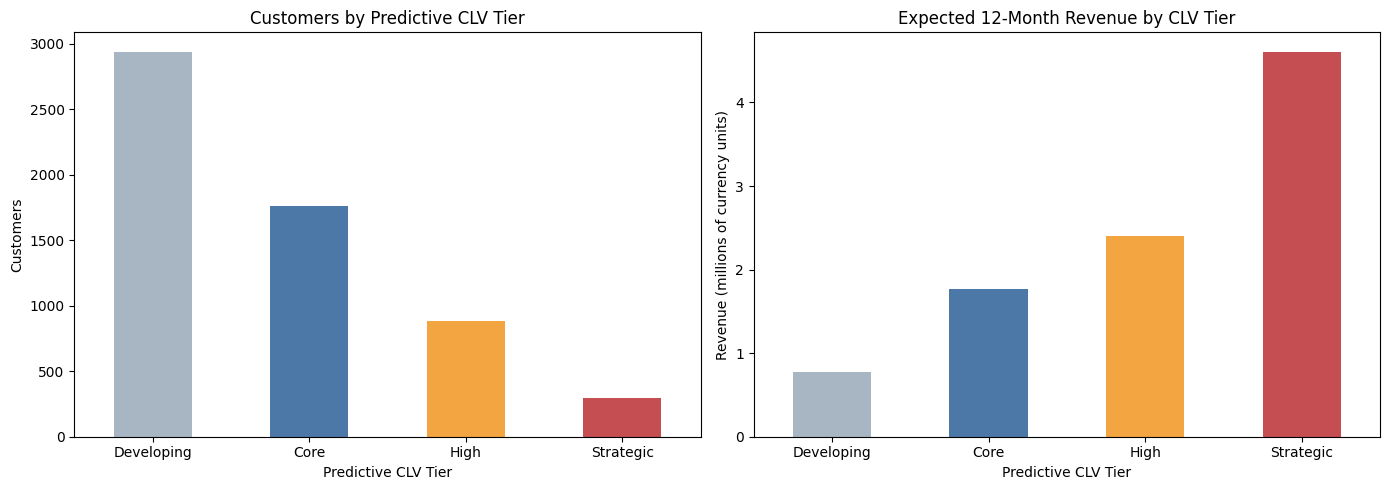

In [32]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

tier_plot = clv_tier_summary.set_index("clv_value_tier")
tier_colors = ["#A7B6C2", "#4C78A8", "#F2A541", "#C44E52"]

tier_plot["customers"].plot(
    kind="bar",
    ax=axes[0],
    color=tier_colors,
)
axes[0].set_title("Customers by Predictive CLV Tier")
axes[0].set_xlabel("Predictive CLV Tier")
axes[0].set_ylabel("Customers")
axes[0].tick_params(axis="x", rotation=0)

(tier_plot["total_expected_revenue_clv_12m"] / 1_000_000).plot(
    kind="bar",
    ax=axes[1],
    color=tier_colors,
)
axes[1].set_title("Expected 12-Month Revenue by CLV Tier")
axes[1].set_xlabel("Predictive CLV Tier")
axes[1].set_ylabel("Revenue (millions of currency units)")
axes[1].tick_params(axis="x", rotation=0)

fig.tight_layout()
fig.savefig(
    FIGURES_DIR / "clv_value_tiers.png",
    dpi=160,
    bbox_inches="tight",
)
plt.show()

### Historical revenue is not predictive revenue CLV

`historical_revenue` is the revenue already observed over the full transaction history. `expected_revenue_clv_12m` is revenue expected **after the observation date** from the BG/NBD and Gamma-Gamma models. The two measures are shown together for context, but they are never added together and should not be interpreted as the same time window.

A long historical record can coexist with low future value when purchasing appears to have stopped. Conversely, a newer customer can have modest historical revenue but meaningful predictive value. Because cost and margin data are unavailable, predictive CLV is revenue—not profit.

,value
Total historical revenue,"17,685,460.638"
Total expected 12-month revenue CLV,"9,556,553.969"
Historical / predictive Pearson correlation,0.909
Historical / predictive Spearman correlation,0.727


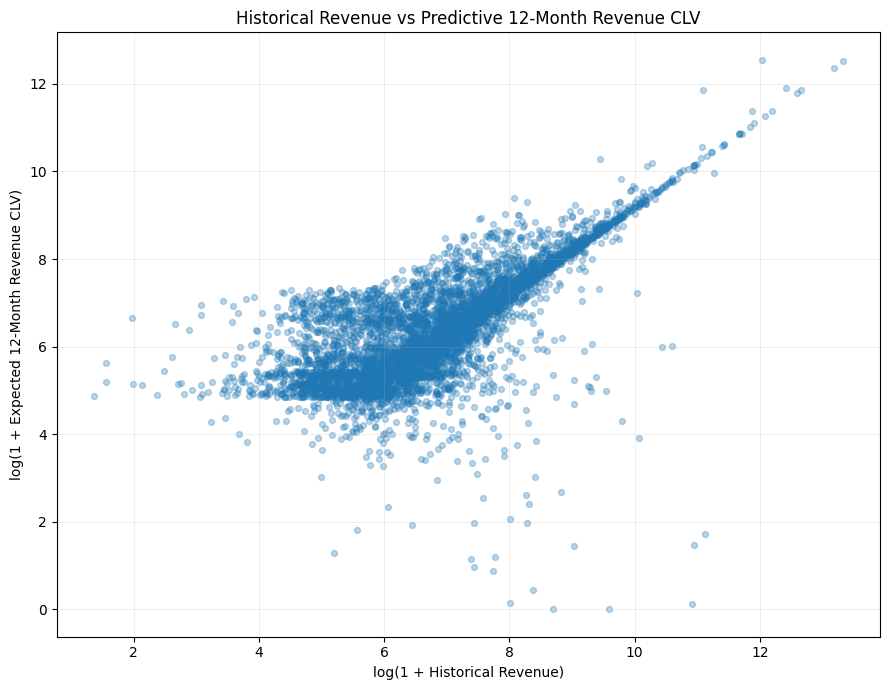

In [33]:
historical_predictive_comparison = pd.Series(
    {
        "Total historical revenue": clv_results[
            "historical_revenue"
        ].sum(),
        "Total expected 12-month revenue CLV": clv_results[
            "expected_revenue_clv_12m"
        ].sum(),
        "Historical / predictive Pearson correlation": clv_results[
            ["historical_revenue", "expected_revenue_clv_12m"]
        ].corr(method="pearson").iloc[0, 1],
        "Historical / predictive Spearman correlation": clv_results[
            ["historical_revenue", "expected_revenue_clv_12m"]
        ].corr(method="spearman").iloc[0, 1],
    },
    name="value",
)

display(historical_predictive_comparison.to_frame())

plt.figure(figsize=(9, 7))
plt.scatter(
    np.log1p(clv_results["historical_revenue"]),
    np.log1p(clv_results["expected_revenue_clv_12m"]),
    alpha=0.30,
    s=18,
)
plt.title("Historical Revenue vs Predictive 12-Month Revenue CLV")
plt.xlabel("log(1 + Historical Revenue)")
plt.ylabel("log(1 + Expected 12-Month Revenue CLV)")
plt.grid(alpha=0.2)
plt.tight_layout()
plt.savefig(
    FIGURES_DIR / "clv_historical_vs_predictive.png",
    dpi=160,
    bbox_inches="tight",
)
plt.show()

## RFM and machine-learning segment integration

RFM answers *how recently, how often, and how much has this customer purchased?* The ML clusters add multivariate behavioral profiles. Predictive CLV answers *how much future revenue does the probabilistic model expect?* Keeping all three views allows business teams to distinguish customers with similar future value but different engagement histories and service needs.

Only the required fields are merged, using one-to-one key validation. The historical RFM tier is renamed so it cannot be confused with the new predictive CLV tier.

In [34]:
rfm_segments = pd.read_parquet(RFM_SEGMENTS_PATH)
ml_segments = pd.read_parquet(ML_SEGMENTS_PATH)

for dataframe in [clv_results, rfm_segments, ml_segments]:
    dataframe["customer_id"] = dataframe["customer_id"].astype("string")

rfm_dimensions = (
    rfm_segments[
        [
            "customer_id",
            "segment",
            "value_tier",
            "rfm_total_score",
            "recommended_action",
        ]
    ]
    .rename(
        columns={
            "segment": "rfm_segment",
            "value_tier": "rfm_value_tier",
            "recommended_action": "rfm_action",
        }
    )
)

ml_dimensions = ml_segments[
    [
        "customer_id",
        "ml_cluster",
        "cluster_name",
        "cluster_action",
    ]
]

assert rfm_dimensions["customer_id"].is_unique
assert ml_dimensions["customer_id"].is_unique

clv_results = (
    clv_results
    .merge(
        rfm_dimensions,
        on="customer_id",
        how="left",
        validate="one_to_one",
    )
    .merge(
        ml_dimensions,
        on="customer_id",
        how="left",
        validate="one_to_one",
    )
)

display(
    clv_results[
        [
            "customer_id",
            "historical_revenue",
            "expected_revenue_clv_12m",
            "clv_value_tier",
            "rfm_segment",
            "rfm_value_tier",
            "cluster_name",
        ]
    ]
    .sort_values("expected_revenue_clv_12m", ascending=False)
    .head(25)
)

,customer_id,historical_revenue,expected_revenue_clv_12m,clv_value_tier,rfm_segment,rfm_value_tier,cluster_name
4061,16446,"168,472.500","282,508.432",Strategic,Potential Loyalists,High Value,High-Value Loyal Customers
5692,18102,"608,821.650","273,487.408",Strategic,Champions,High Value,High-Value Loyal Customers
2277,14646,"528,602.520","235,743.545",Strategic,Champions,High Value,High-Value Loyal Customers
5050,17450,"246,813.090","149,104.658",Strategic,Champions,High Value,High-Value Loyal Customers
1731,14096,"65,164.790","140,633.861",Strategic,Champions,High Value,High-Value Loyal Customers
1789,14156,"313,759.820","140,366.175",Strategic,Champions,High Value,High-Value Loyal Customers
2538,14911,"295,832.390","132,604.524",Strategic,Champions,High Value,High-Value Loyal Customers
1331,13694,"196,482.810","87,689.561",Strategic,Champions,High Value,High-Value Loyal Customers
68,12415,"144,458.370","86,857.053",Strategic,Champions,High Value,High-Value Loyal Customers
5109,17511,"175,603.550","78,002.037",Strategic,Champions,High Value,High-Value Loyal Customers


In [35]:
def summarize_clv_by_dimension(
    dataframe: pd.DataFrame,
    dimension: str,
) -> pd.DataFrame:
    summary = (
        dataframe
        .groupby(dimension, observed=True)
        .agg(
            customers=("customer_id", "nunique"),
            total_historical_revenue=("historical_revenue", "sum"),
            total_expected_revenue_clv_12m=(
                "expected_revenue_clv_12m",
                "sum",
            ),
            mean_expected_revenue_clv_12m=(
                "expected_revenue_clv_12m",
                "mean",
            ),
            median_expected_revenue_clv_12m=(
                "expected_revenue_clv_12m",
                "median",
            ),
            mean_probability_alive=("probability_alive", "mean"),
        )
        .reset_index()
    )

    summary["predictive_revenue_share_pct"] = (
        summary["total_expected_revenue_clv_12m"]
        / summary["total_expected_revenue_clv_12m"].sum()
        * 100
    )

    return summary.sort_values(
        "total_expected_revenue_clv_12m",
        ascending=False,
    ).reset_index(drop=True)


clv_rfm_segment_summary = summarize_clv_by_dimension(
    clv_results,
    "rfm_segment",
)

clv_ml_cluster_summary = summarize_clv_by_dimension(
    clv_results,
    "cluster_name",
)

clv_rfm_tier_crosstab = pd.crosstab(
    clv_results["rfm_segment"],
    clv_results["clv_value_tier"],
    margins=True,
)

display(clv_rfm_segment_summary)
display(clv_ml_cluster_summary)
display(clv_rfm_tier_crosstab)

,rfm_segment,customers,total_historical_revenue,total_expected_revenue_clv_12m,mean_expected_revenue_clv_12m,median_expected_revenue_clv_12m,mean_probability_alive,predictive_revenue_share_pct
0,Champions,1423,"12,189,047.705","6,299,907.320","4,427.201","2,088.968",0.984,65.922
1,Loyal Customers,1190,"2,561,370.566","1,501,979.610","1,262.168",838.004,0.944,15.717
2,Potential Loyalists,261,"339,225.110","544,882.521","2,087.672",672.187,0.945,5.702
3,About to Sleep,913,"399,892.470","334,773.663",366.674,296.831,0.948,3.503
4,Cannot Lose Them,298,"1,056,759.032","186,409.184",625.534,387.264,0.530,1.951
5,At Risk,431,"518,199.940","173,782.675",403.208,295.778,0.688,1.818
6,Promising,164,"54,716.410","160,667.687",979.681,980.814,1.000,1.681
7,Hibernating,954,"418,462.662","159,868.064",167.577,156.665,0.918,1.673
8,New Customers,75,"26,034.480","100,117.346","1,334.898","1,321.471",1.000,1.048
9,Need Attention,169,"121,752.263","94,165.900",557.195,413.023,0.906,0.985


,cluster_name,customers,total_historical_revenue,total_expected_revenue_clv_12m,mean_expected_revenue_clv_12m,median_expected_revenue_clv_12m,mean_probability_alive,predictive_revenue_share_pct
0,High-Value Loyal Customers,1455,"13,801,571.081","6,980,234.619","4,797.412","2,265.067",0.956,73.041
1,Established Moderate-Value Customers,1848,"2,166,314.313","1,371,859.407",742.348,505.252,0.863,14.355
2,Dormant One-Time Customers,1589,"514,791.752","612,327.953",385.354,219.814,0.968,6.407
3,At-Risk Return-Heavy Customers,986,"1,202,783.492","592,131.990",600.540,375.176,0.845,6.196


clv_value_tier,Developing,Core,High,Strategic,All
rfm_segment,,,,,
About to Sleep,754,158,1,0,913
At Risk,375,53,2,1,431
Cannot Lose Them,198,85,13,2,298
Champions,80,486,599,258,1423
Hibernating,947,7,0,0,954
Loyal Customers,373,561,229,27,1190
Need Attention,107,57,5,0,169
New Customers,0,75,0,0,75
Potential Loyalists,105,117,33,6,261


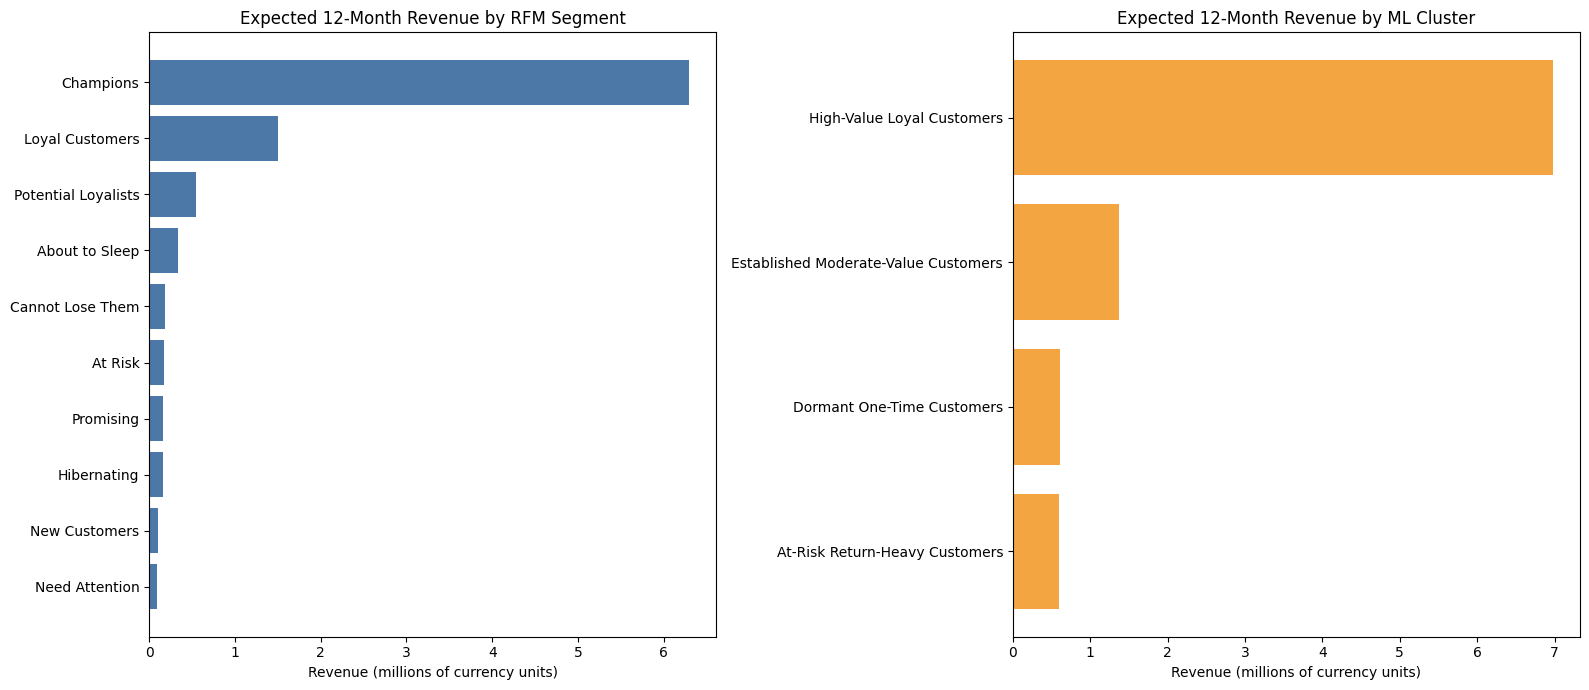

In [36]:
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

rfm_plot = clv_rfm_segment_summary.sort_values(
    "total_expected_revenue_clv_12m"
)
axes[0].barh(
    rfm_plot["rfm_segment"],
    rfm_plot["total_expected_revenue_clv_12m"] / 1_000_000,
    color="#4C78A8",
)
axes[0].set_title("Expected 12-Month Revenue by RFM Segment")
axes[0].set_xlabel("Revenue (millions of currency units)")

cluster_plot = clv_ml_cluster_summary.sort_values(
    "total_expected_revenue_clv_12m"
)
axes[1].barh(
    cluster_plot["cluster_name"],
    cluster_plot["total_expected_revenue_clv_12m"] / 1_000_000,
    color="#F2A541",
)
axes[1].set_title("Expected 12-Month Revenue by ML Cluster")
axes[1].set_xlabel("Revenue (millions of currency units)")

fig.tight_layout()
fig.savefig(
    FIGURES_DIR / "clv_business_segments.png",
    dpi=160,
    bbox_inches="tight",
)
plt.show()

## Interpretation and model boundaries

- Historical validation is strong at the portfolio level: 7,960.962 predicted purchases versus 8,111 actual purchases in the 191-day holdout, an aggregate error of −1.85%. Individual predictions remain noisy (MAE 1.078; RMSE 1.843), so CLV is best used for ranking and portfolio planning rather than as a promise for one customer.
- The frequency/monetary correlation is 0.0233 for 4,189 repeat customers, supporting the Gamma-Gamma independence assumption. Customers without a repeat purchase are scored using the fitted population-level spend expectation; their own monetary evidence is limited.
- `probability_alive` is the BG/NBD model's latent purchasing-status estimate. It is not an observed churn label and is not interchangeable with the separate supervised churn probability used in the next notebook.
- Transactions are aggregated to customer purchase-days for model consistency. The expected transaction value therefore represents an expected future purchase-day value, which can contain multiple invoices.
- The final models use maximum a posteriori (MAP) estimates and the reported forecasts are point expectations. Credible or predictive intervals are not estimated here, so uncertainty should be addressed through sensitivity analysis or fuller posterior sampling before high-stakes commitments.
- The distribution contains wholesale-like outliers. They are retained because they are valid sales, but concentration and account-level review are essential before large commitments.

In [37]:
prediction_columns = [
    "probability_alive",
    "expected_purchases_90d",
    "expected_purchases_180d",
    "expected_purchases_365d",
    "expected_transaction_value",
    "expected_revenue_clv_12m",
]

assert clv_results["customer_id"].is_unique
assert len(clv_results) == len(clv_rfm) == 5_878
assert not clv_results[prediction_columns].isna().any().any()
assert np.isfinite(
    clv_results[prediction_columns].to_numpy(dtype="float64")
).all()
assert clv_results["probability_alive"].between(0, 1).all()
assert (clv_results[prediction_columns[1:]] >= 0).all().all()
assert (
    clv_results["expected_purchases_90d"]
    <= clv_results["expected_purchases_180d"]
).all()
assert (
    clv_results["expected_purchases_180d"]
    <= clv_results["expected_purchases_365d"]
).all()
assert not clv_results[
    [
        "rfm_segment",
        "rfm_value_tier",
        "cluster_name",
        "clv_value_tier",
    ]
].isna().any().any()

print("Final CLV customer-level validation passed.")

Final CLV customer-level validation passed.


In [38]:
CLV_CSV_PATH = REPORTS_DIR / "customer_clv.csv"
CLV_SUMMARY_PATH = REPORTS_DIR / "clv_model_summary.json"

clv_results = clv_results.sort_values("customer_id").reset_index(drop=True)

clv_results.to_parquet(OUTPUT_PATH, index=False)
clv_results.to_csv(CLV_CSV_PATH, index=False)

clv_tier_thresholds.to_csv(
    REPORTS_DIR / "clv_tier_thresholds.csv",
    index=False,
)
clv_tier_summary.to_csv(
    REPORTS_DIR / "clv_tier_summary.csv",
    index=False,
)
clv_rfm_segment_summary.to_csv(
    REPORTS_DIR / "clv_rfm_segment_summary.csv",
    index=False,
)
clv_ml_cluster_summary.to_csv(
    REPORTS_DIR / "clv_ml_cluster_summary.csv",
    index=False,
)
clv_rfm_tier_crosstab.to_csv(
    REPORTS_DIR / "clv_rfm_tier_crosstab.csv",
)
clv_results.nlargest(100, "expected_revenue_clv_12m").to_csv(
    REPORTS_DIR / "clv_top_100_customers.csv",
    index=False,
)

clv_model_summary = {
    "observation_end": str(customer_sales["invoice_date"].max()),
    "customers": int(len(clv_results)),
    "holdout_customers": int(len(clv_validation)),
    "holdout_days": int(clv_train_test["test_T"].iloc[0]),
    "holdout_mae": float(purchase_mae),
    "holdout_rmse": float(purchase_rmse),
    "holdout_actual_purchases": float(actual_total_purchases),
    "holdout_predicted_purchases": float(predicted_total_purchases),
    "holdout_aggregate_error_pct": float(
        (predicted_total_purchases - actual_total_purchases)
        / actual_total_purchases
        * 100
    ),
    "gamma_gamma_eligible_customers": int(len(gamma_data)),
    "frequency_monetary_correlation": float(
        frequency_monetary_correlation
    ),
    "expected_revenue_clv_12m_total": float(
        clv_results["expected_revenue_clv_12m"].sum()
    ),
    "expected_revenue_clv_12m_mean": float(
        clv_results["expected_revenue_clv_12m"].mean()
    ),
    "expected_revenue_clv_12m_median": float(clv_p50),
    "clv_tier_cutoffs": {
        "p50": clv_p50,
        "p80": clv_p80,
        "p95": clv_p95,
    },
    "monthly_discount_rate": MONTHLY_DISCOUNT_RATE,
    "clv_definition": (
        "Expected future revenue over 12 months; not historical revenue "
        "and not profit."
    ),
    "bgnbd_map_parameters": {
        str(key): float(value)
        for key, value in final_bgm.fit_summary().items()
    },
    "gamma_gamma_map_parameters": {
        str(key): float(value)
        for key, value in gamma_gamma_model.fit_summary().items()
    },
}

CLV_SUMMARY_PATH.write_text(
    json.dumps(clv_model_summary, indent=2),
    encoding="utf-8",
)

print("=" * 70)
print("CLV modeling pipeline completed successfully")
print("=" * 70)
print(f"Customers:                 {len(clv_results):,}")
print(
    "Expected 12-month revenue: "
    f"{clv_results['expected_revenue_clv_12m'].sum():,.2f}"
)
print(f"Saved customer output:     {OUTPUT_PATH}")
print(f"Saved model summary:       {CLV_SUMMARY_PATH}")

CLV modeling pipeline completed successfully
Customers:                 5,878
Expected 12-month revenue: 9,556,553.97
Saved customer output:     C:\Users\omary\Documents\VS Code\customer-intelligence-analytics\data\processed\customer_clv.parquet
Saved model summary:       C:\Users\omary\Documents\VS Code\customer-intelligence-analytics\reports\clv_model_summary.json


## Final CLV findings

The completed pipeline produces a one-row-per-customer predictive value table for all 5,878 customers, joined to the existing RFM and ML segment dimensions. Portfolio-level BG/NBD validation is well calibrated, while the customer-level errors reinforce using the forecasts for prioritization rather than deterministic budgeting.

The strongest business signal is concentration: a small Strategic tier contains a disproportionate share of expected revenue. Those accounts warrant individual review because the model correctly preserves valid wholesale behavior, but a few unusually large purchase-days can dominate their forecast. The Core and High tiers provide broader, less concentrated audiences for scaled lifecycle programs.

The next stage combines this predictive revenue view with a separately validated churn model. It must preserve the distinction between BG/NBD probability alive and supervised churn probability, and it must treat any intervention response assumption as a scenario—not measured causal uplift.